In [2]:
#1. load data
import pandas as pd
df = pd.read_csv('/content/Dataset_ATS_v2.csv')#load path
df.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [3]:
#we can add a self-defined feature, because tenure implies a potential new user
# which is the length of time a user has been using the service
df = df.copy()
df['IsNewCustomer'] = (df['tenure'] == 0).astype(int)
print(df['IsNewCustomer'].value_counts())


IsNewCustomer
0    7032
1      11
Name: count, dtype: int64


In [4]:
#show the data
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,IsNewCustomer
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.758768,0.001562
std,0.368612,24.559481,30.091650,0.039492
min,0.000000,0.000000,18.000000,0.000000
25%,0.000000,9.000000,36.000000,0.000000
50%,0.000000,29.000000,70.000000,0.000000
75%,0.000000,55.000000,90.000000,0.000000
max,1.000000,72.000000,119.000000,1.000000


In [5]:
# check categorical data with their unique values
categorical_cols = df.select_dtypes(include=['object']).columns
categorical_unique_values = {col: df[col].unique().tolist() for col in categorical_cols}
categorical_unique_values

{'gender': ['Female', 'Male'],
 'Dependents': ['No', 'Yes'],
 'PhoneService': ['No', 'Yes'],
 'MultipleLines': ['No', 'Yes'],
 'InternetService': ['DSL', 'Fiber optic'],
 'Contract': ['Month-to-month', 'One year', 'Two year'],
 'Churn': ['Yes', 'No']}

In [6]:
#see the specific proportion
categorical_value_counts = {
    col: df[col].value_counts().to_dict() for col in categorical_cols
}
categorical_value_counts

{'gender': {'Male': 3555, 'Female': 3488},
 'Dependents': {'No': 4933, 'Yes': 2110},
 'PhoneService': {'Yes': 6361, 'No': 682},
 'MultipleLines': {'No': 4072, 'Yes': 2971},
 'InternetService': {'DSL': 3947, 'Fiber optic': 3096},
 'Contract': {'Month-to-month': 3875, 'Two year': 1695, 'One year': 1473},
 'Churn': {'No': 5174, 'Yes': 1869}}

/tmp/ipykernel_16622/57115170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index,
/tmp/ipykernel_16622/57115170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index,
/tmp/ipykernel_16622/57115170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x=col, order=df[col].value_counts().index,
/tmp/ipykernel_16622/57115170.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.

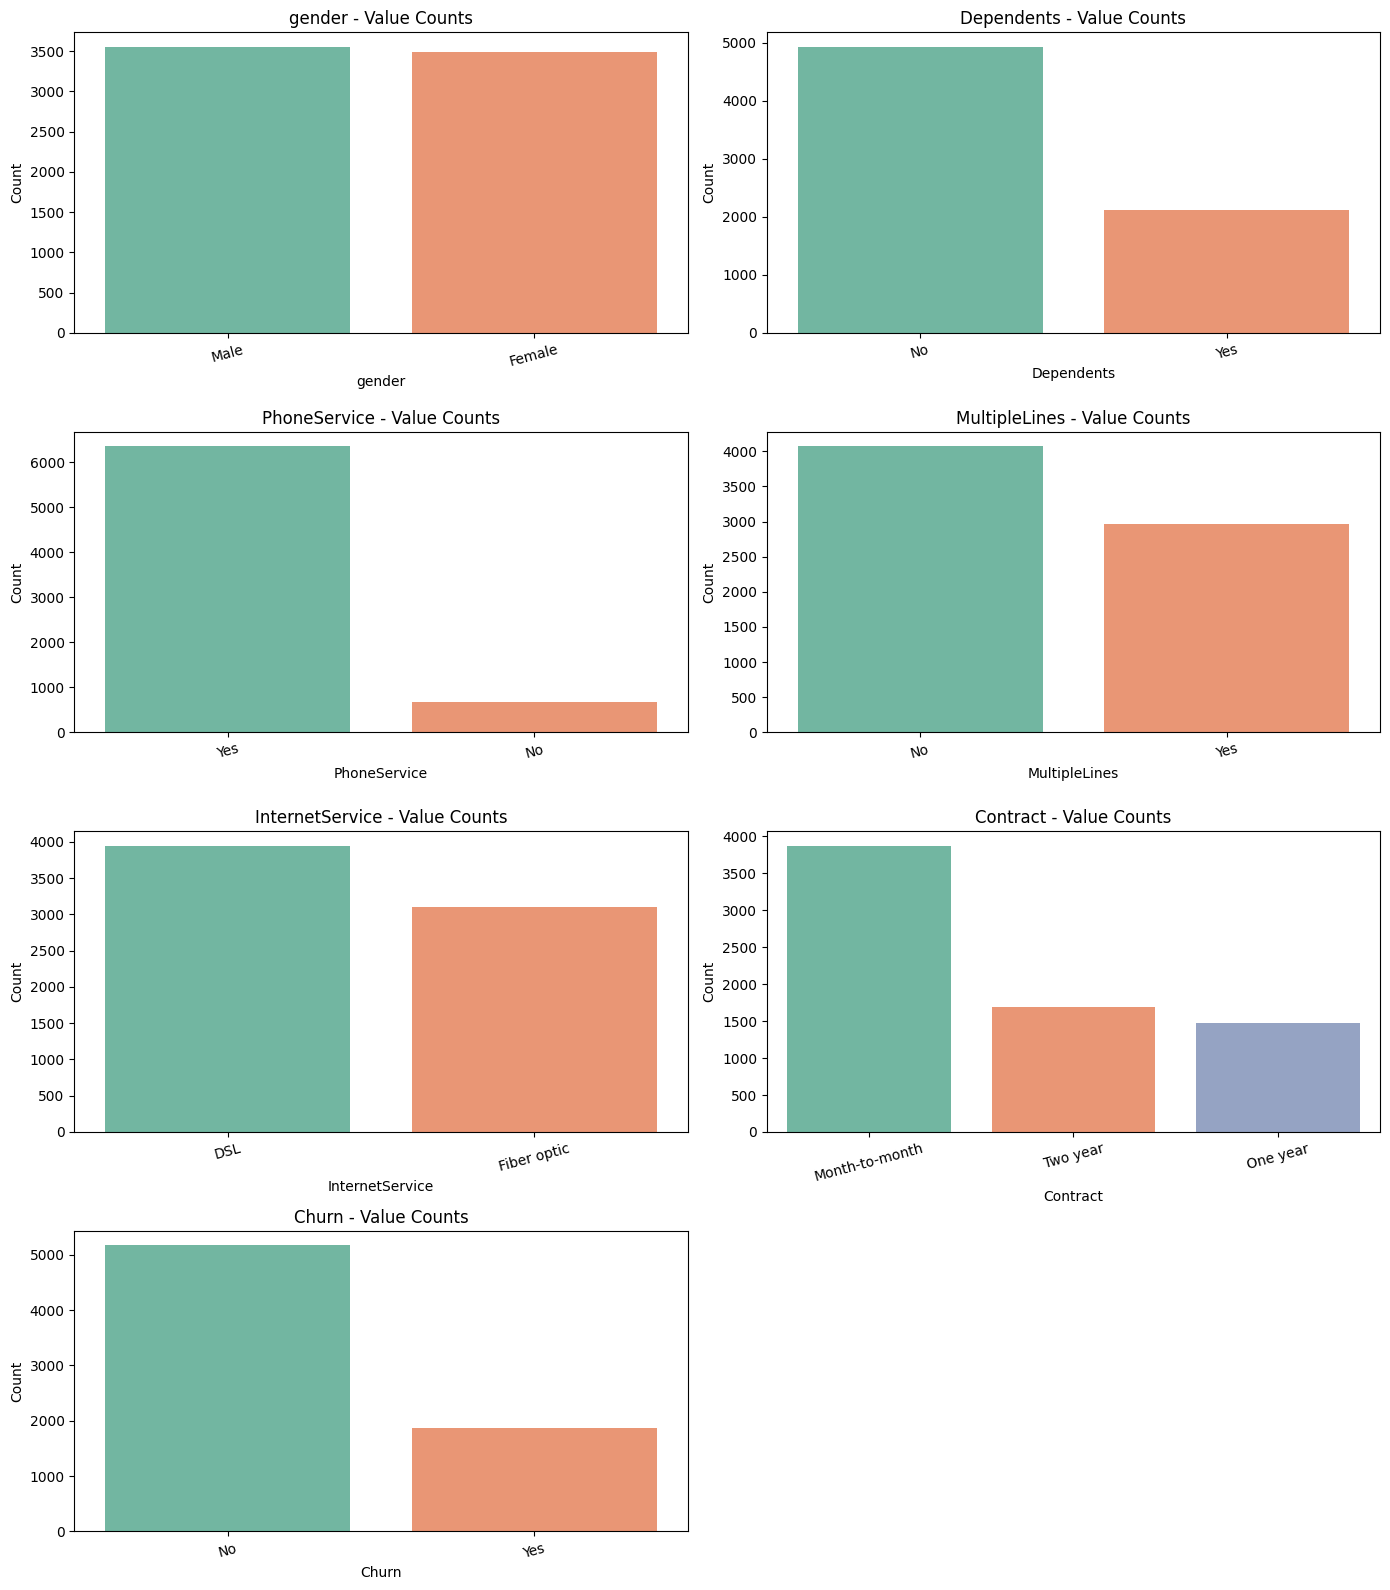

In [7]:
#visualise data distribution (categorical)
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(14, 16))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    n_colors = df[col].nunique()
    local_palette = sns.color_palette("Set2", n_colors)
    sns.countplot(data=df, x=col, order=df[col].value_counts().index,
                  ax=axes[i], palette=local_palette)
    axes[i].set_title(f"{col} - Value Counts")
    axes[i].set_ylabel("Count")
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=15)

for j in range(len(categorical_cols), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

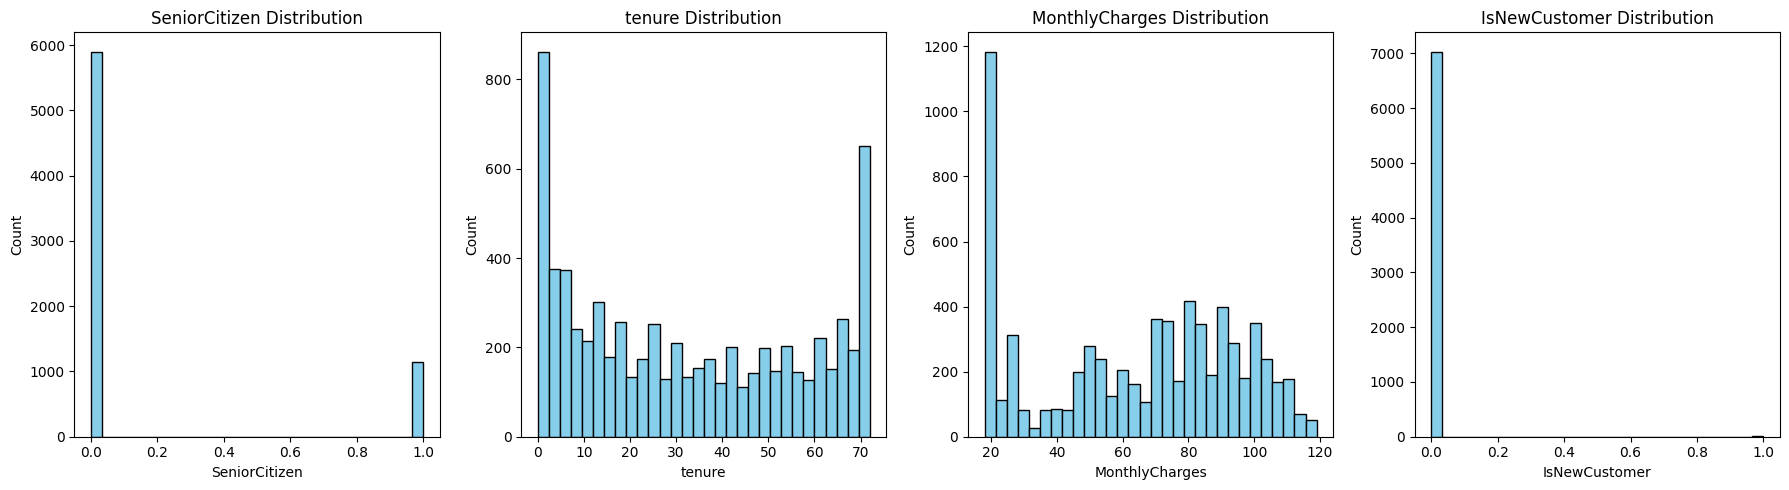

In [8]:
#visualise numerical data
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns

fig, axes = plt.subplots(nrows=1, ncols=len(numeric_cols), figsize=(18, 5))

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color='skyblue', edgecolor='black')
    axes[i].set_title(f"{col} Distribution")
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Count")

plt.tight_layout()
plt.show()

In [9]:
df

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn,IsNewCustomer
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes,0
1,Male,0,No,41,Yes,No,DSL,One year,25,No,0
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No,0
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes,0
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No,0
...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,No,1,Yes,Yes,DSL,One year,95,Yes,0
7039,Female,0,Yes,23,Yes,Yes,Fiber optic,One year,91,No,0
7040,Male,0,Yes,12,Yes,No,DSL,Month-to-month,21,No,0
7041,Male,1,No,12,Yes,Yes,Fiber optic,Month-to-month,99,Yes,0


In [10]:
from sklearn.preprocessing import MinMaxScaler

label_column = 'Churn' # y-label
if label_column in df.columns:
    label = df.pop(label_column)
    df[label_column] = label

df[label_column] = df[label_column].map({'Yes': 1, 'No': 0}).astype(int)

# only feature Contract will be processed through one-hot
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object', 'category', 'bool']).columns.tolist()
numerical_cols = [col for col in numerical_cols if col != label_column]
categorical_cols = [col for col in categorical_cols if col != label_column]

# other numerical values will be normalized by minmaxscaler
scaler = MinMaxScaler()
df_numerical = pd.DataFrame(scaler.fit_transform(df[numerical_cols]), columns=numerical_cols)

df_contract = pd.get_dummies(df[['Contract']], prefix='Contract')
binary_cats = [col for col in categorical_cols if col != 'Contract']
df_binary = df[binary_cats].apply(lambda x: x.astype('category').cat.codes)

df_processed = pd.concat([df_numerical, df_binary, df_contract, df[label_column]], axis=1)
df_processed.to_csv('/Dataset_processed_for_ANN.csv', index=False)


In [11]:
df_processed

,SeniorCitizen,tenure,MonthlyCharges,IsNewCustomer,gender,Dependents,PhoneService,MultipleLines,InternetService,Contract_Month-to-month,Contract_One year,Contract_Two year,Churn
0,0.0,0.013889,0.069307,0.0,0,0,0,0,0,True,False,False,1
1,0.0,0.569444,0.069307,0.0,1,0,1,0,0,False,True,False,0
2,0.0,0.722222,0.009901,0.0,0,1,1,0,0,True,False,False,0
3,0.0,0.013889,0.574257,0.0,0,0,1,0,0,False,True,False,1
4,0.0,0.930556,0.326733,0.0,1,0,1,0,1,True,False,False,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0.0,0.013889,0.762376,0.0,1,0,1,1,0,False,True,False,1
7039,0.0,0.319444,0.722772,0.0,0,1,1,1,1,False,True,False,0
7040,0.0,0.166667,0.029703,0.0,1,1,1,0,0,True,False,False,0
7041,1.0,0.166667,0.801980,0.0,1,0,1,1,1,True,False,False,1


In [12]:
gender_mapping = dict(enumerate(df['gender'].astype('category').cat.categories))
print(gender_mapping)


{0: 'Female', 1: 'Male'}


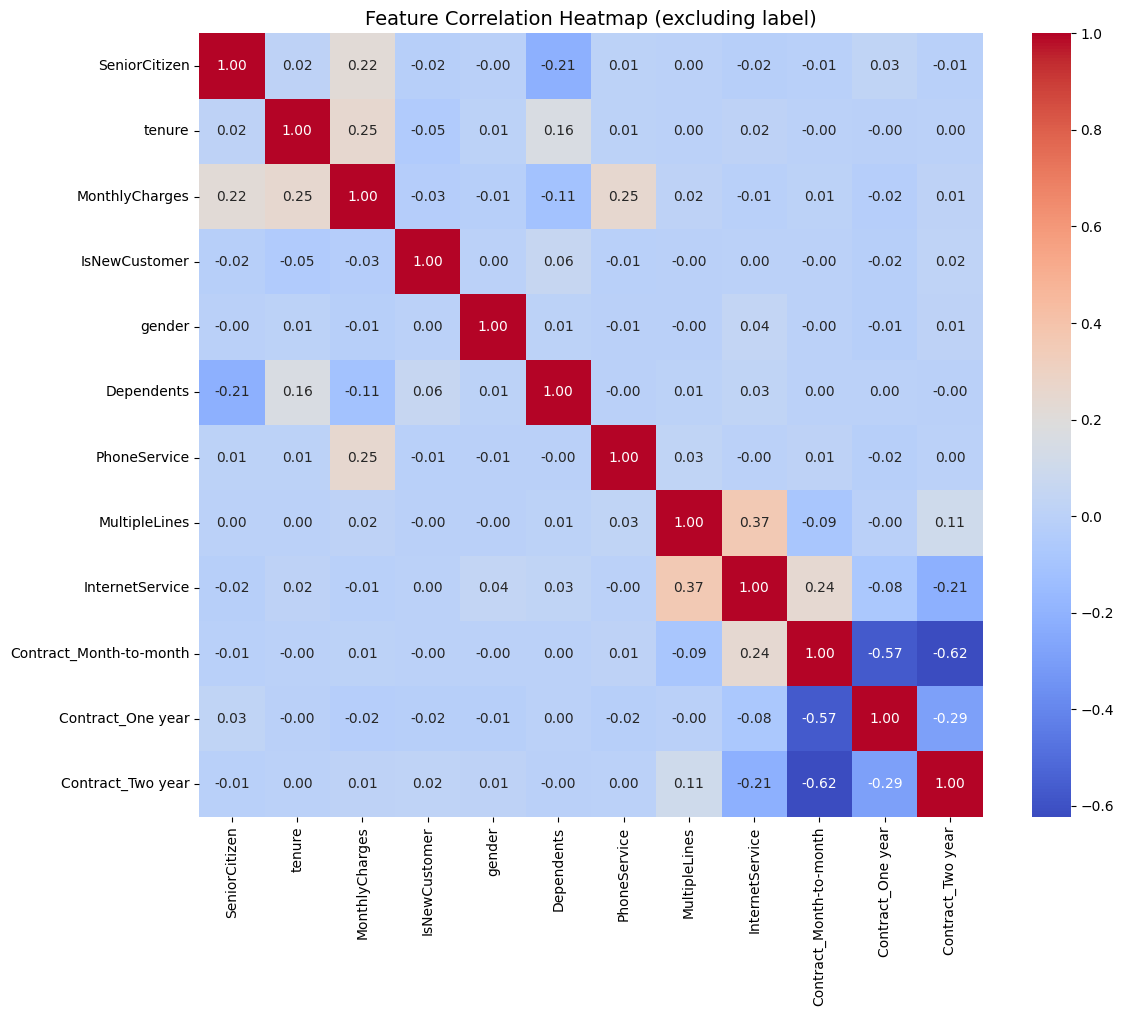

In [13]:
#heatmap
corr_matrix = df_processed.drop(columns=['Churn']).corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True, cbar=True)
plt.title('Feature Correlation Heatmap (excluding label)', fontsize=14)
plt.tight_layout()
plt.show()

/tmp/ipykernel_16622/3914962172.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cor_with_label.values, y=cor_with_label.index, palette='crest')


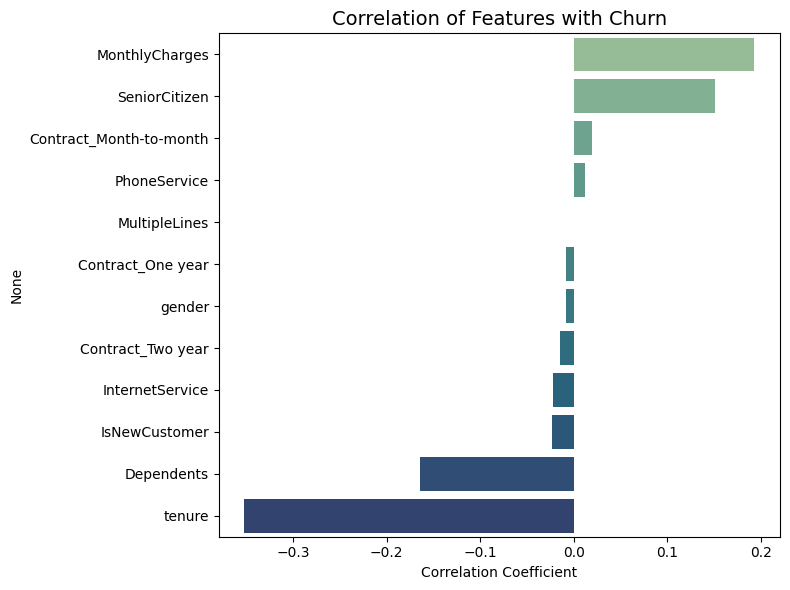

In [14]:
#corellation betweensfeatures and label

cor_with_label = df_processed.corr()['Churn'].drop('Churn').sort_values(ascending=False)

plt.figure(figsize=(8, 6))
sns.barplot(x=cor_with_label.values, y=cor_with_label.index, palette='crest')
plt.title('Correlation of Features with Churn', fontsize=14)
plt.xlabel('Correlation Coefficient')
plt.tight_layout()
plt.show()


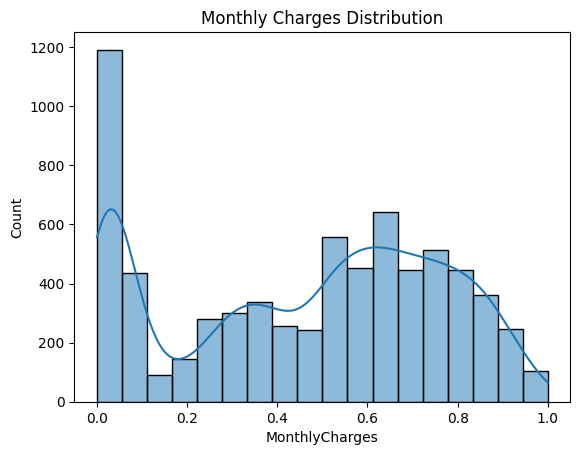

In [15]:
sns.histplot(df_processed['MonthlyCharges'], kde=True)
plt.title("Monthly Charges Distribution")
plt.show()


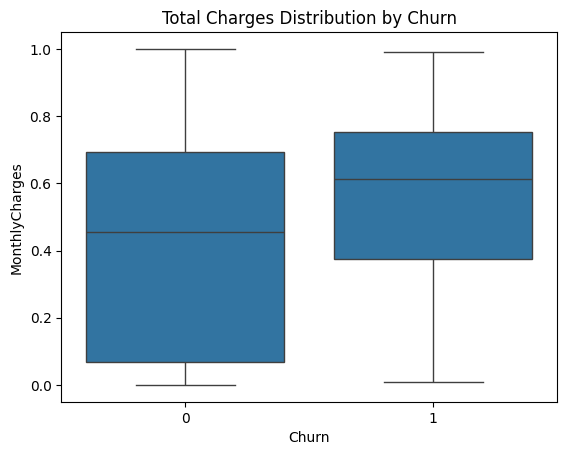

In [16]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df_processed)
plt.title("Total Charges Distribution by Churn")
plt.show()


In [18]:
from sklearn.model_selection import train_test_split

X = df_processed.drop('Churn', axis=1)
y = df_processed['Churn']
y = y.astype(int)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [20]:

train_df = pd.concat([X_train, y_train], axis=1)

test_df = pd.concat([X_test, y_test], axis=1)

train_df.to_csv('train.csv', index=False)
test_df.to_csv('test.csv', index=False)